In [1]:
import os
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio 
import numpy as np
from sklearn.preprocessing import minmax_scale
import pandas as pd
from scipy.stats import skew, kurtosis

# Feature Extraction on Sample File

In [2]:
SAMPLE_PATH = os.path.join('..', '..', 'data', 'train', 'ANG', '1001_DFA_ANG_XX.mp3')
x, sr = librosa.load(SAMPLE_PATH)

In [3]:
Audio(x, rate=sr)

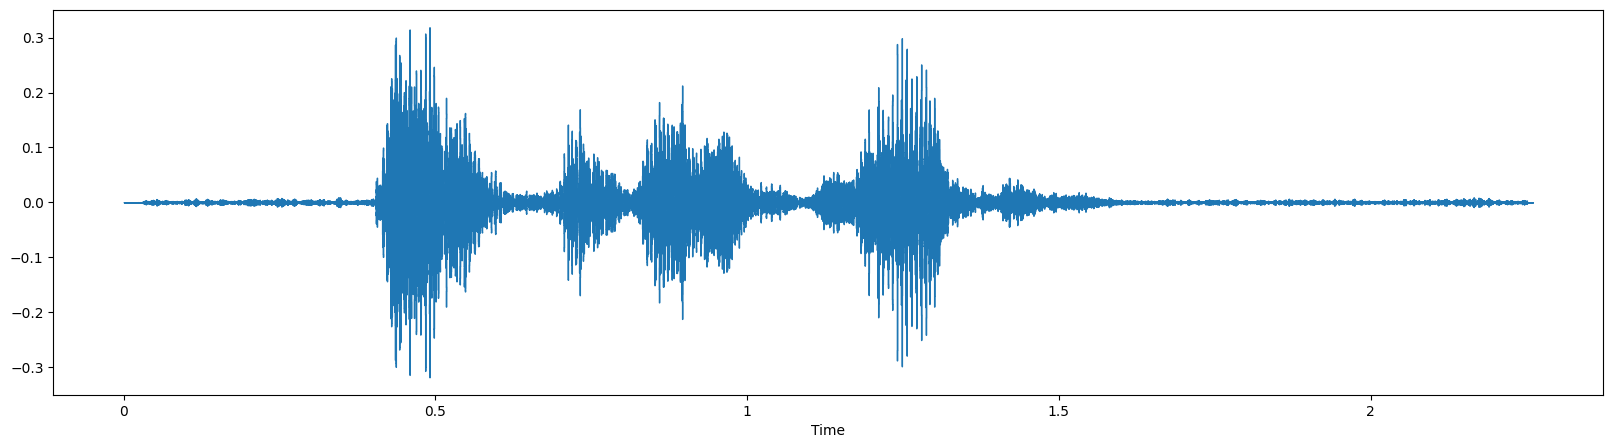

In [8]:
plt.figure(figsize=(20, 5))
librosa.display.waveshow(x, sr=sr)

In [9]:
# split into ten frames
n_frames_desired = 10
frame_length = x.shape[0] // n_frames_desired
hop_length = frame_length

## Zero Crossing Rate

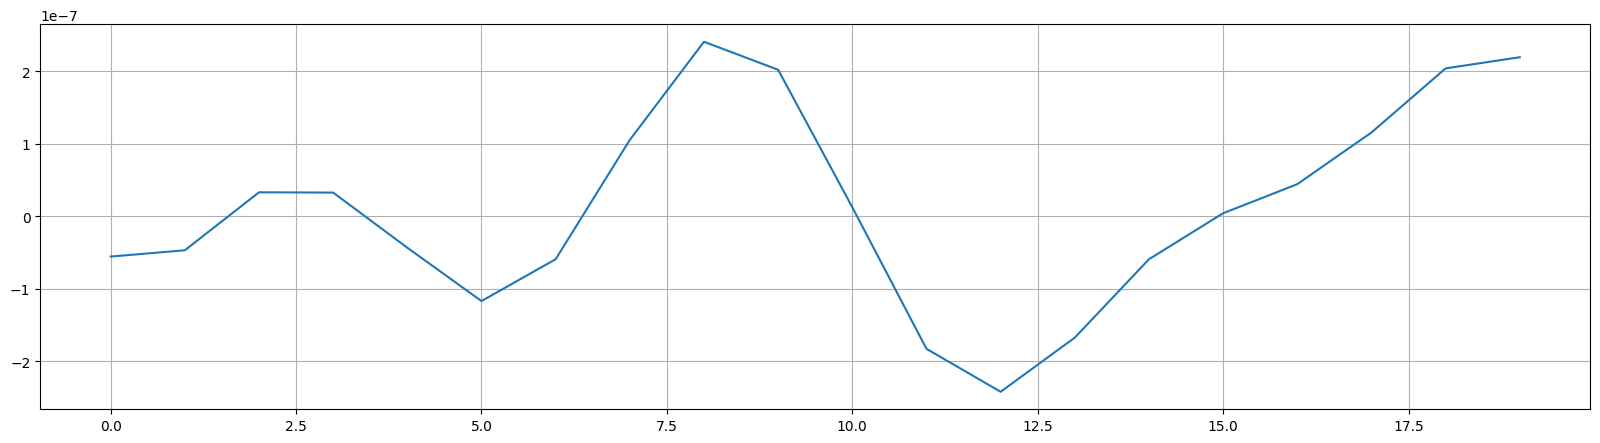

In [10]:
# zoom in -- there are 5 zero crossings visible in the plot 
n0 = 0
n1 = 20
plt.figure(figsize=(20, 5))
plt.plot(x[n0:n1])
plt.grid()

(10, 1)


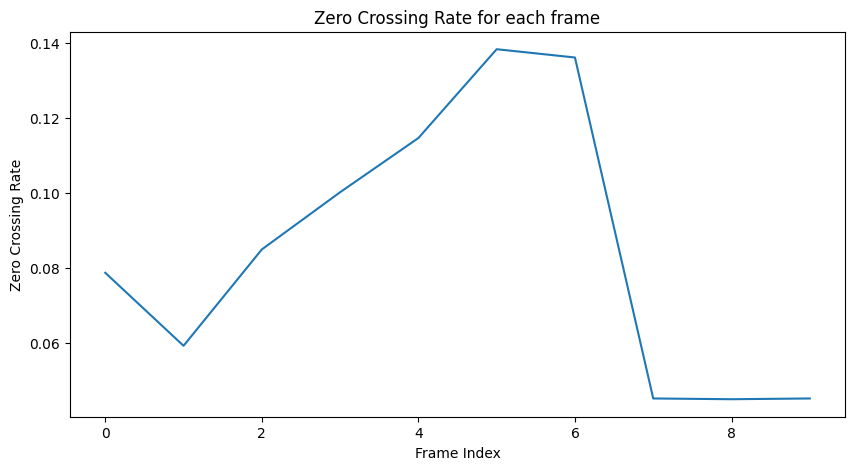

In [11]:
frames = librosa.util.frame(x, frame_length=frame_length, hop_length=hop_length)

zcrs = []
for i in range(frames.shape[1]):
    frame = frames[:, i]
    zcr = librosa.feature.zero_crossing_rate(
        frame.reshape(1, -1),
        frame_length=frame.size,
        hop_length=frame.size,
        center=False
    )
    zcrs.append(zcr[0, 0])

zcrs = np.array(zcrs)
print(zcrs.shape)

plt.figure(figsize=(10, 5))
plt.plot(zcrs)
plt.title('Zero Crossing Rate for each frame')
plt.xlabel('Frame Index')
plt.ylabel('Zero Crossing Rate')
plt.show()


# Root Mean Square Energy (RMSE)

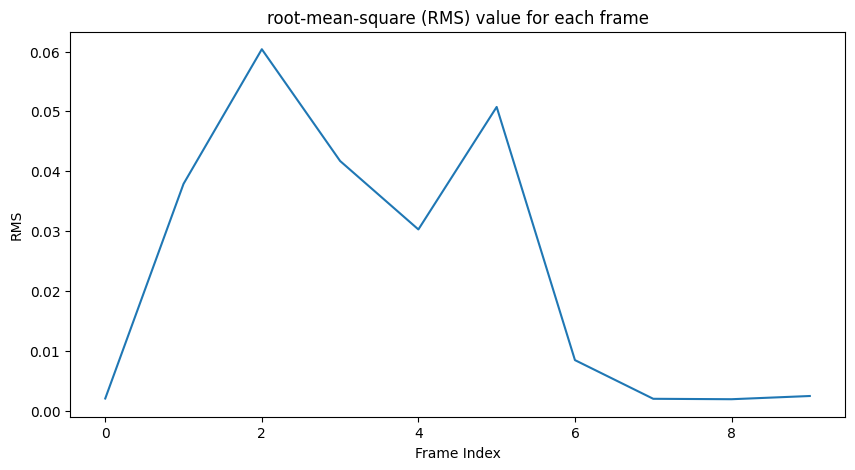

In [12]:
frames = librosa.util.frame(x, frame_length=frame_length, hop_length=hop_length)

rmss = []
for i in range(frames.shape[1]):
    frame = frames[:, i]
    rms = librosa.feature.rms(
        y= frame.reshape(1, -1),
        frame_length=frame.size,
        hop_length=frame.size,
        center=False
    )
    rmss.append(rms[0, 0])

rmss = np.array(rmss)

# plot the zcr for each frame
plt.figure(figsize=(10, 5))
plt.plot(rmss)
plt.title('root-mean-square (RMS) value for each frame')
plt.xlabel('Frame Index')
plt.ylabel('RMS')
plt.show()

## Temporal Centroid

Temporal Centroid (seconds): 0.6742193075416943


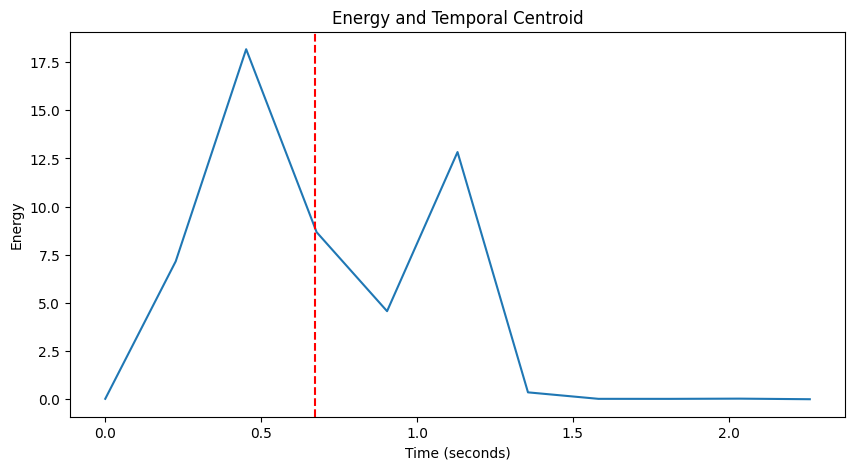

In [13]:
# power is proportional to the square of the amplitude
energy = np.array([
    sum(abs(x[i:i+frame_length]**2))
    for i in range(0, len(x), hop_length)
])

times = librosa.frames_to_time(np.arange(len(energy)), sr=sr, hop_length=hop_length)

# Temporal centroid = weighted average of times by energy
temporal_centroid = np.sum(times * energy) / np.sum(energy)

print(f"Temporal Centroid (seconds): {temporal_centroid}")

# plot the energy and temporal centroid
plt.figure(figsize=(10, 5))
plt.plot(times, energy)
plt.axvline(x=temporal_centroid, color='r', linestyle='--')
plt.title('Energy and Temporal Centroid')
plt.xlabel('Time (seconds)')
plt.ylabel('Energy')
plt.show()

## Spectral Centroid / Spectral Bandwidth

In [14]:
spectral_centroids = librosa.feature.spectral_centroid(y = x, sr = sr)[0]
spectral_centroids = spectral_centroids.flatten()
spectral_centroids.shape

spectral_bandwidth = librosa.feature.spectral_bandwidth(y=x, sr=sr)[0]
spectral_bandwidth = spectral_bandwidth.flatten()
spectral_bandwidth.shape

(98,)

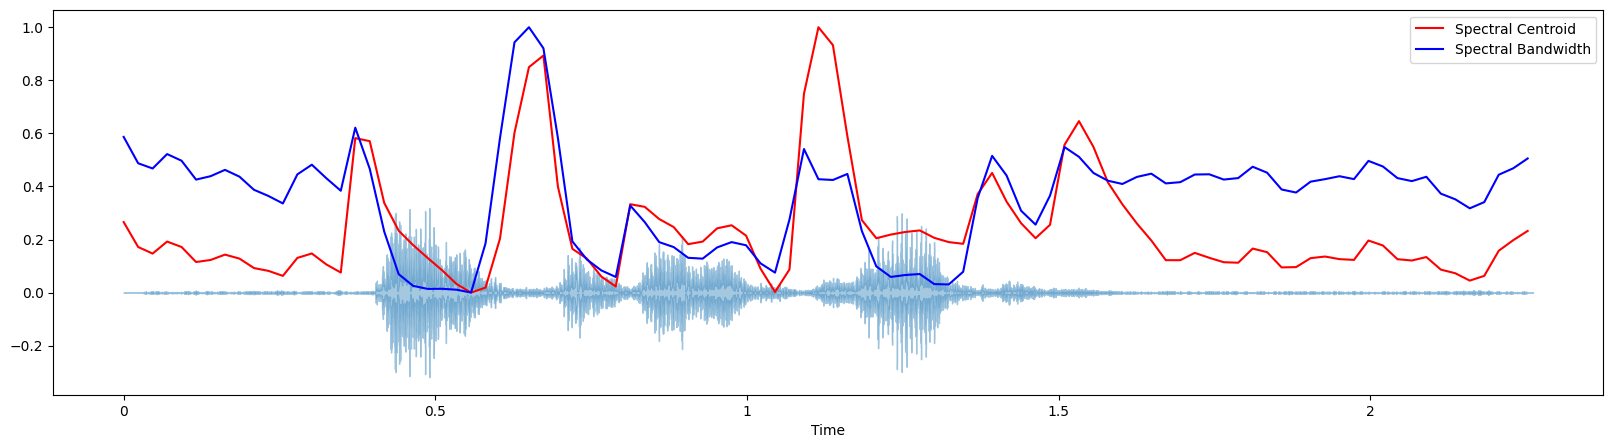

In [15]:
plt.figure(figsize=(20,5))
frames = range(len(spectral_centroids))
t = librosa.frames_to_time(frames, sr=sr)

def normalize(x, axis=0):
    return minmax_scale(x, axis=axis)

#Plotting the Spectral Centroid along the waveform
librosa.display.waveshow(x, sr=sr, alpha=0.4)
plt.plot(t, normalize(spectral_centroids), color='r', label='Spectral Centroid')
plt.plot(t, normalize(spectral_bandwidth), color='b', label='Spectral Bandwidth')
plt.legend()
plt.show()

In [16]:
centroid_mean = np.mean(spectral_centroids)
centroid_std = np.std(spectral_centroids)
centroid_min = np.min(spectral_centroids)
centroid_max = np.max(spectral_centroids)
centroid_skew = skew(spectral_centroids)
centroid_kurt = kurtosis(spectral_centroids)

bandwidth_mean = np.mean(spectral_bandwidth)
bandwidth_std = np.std(spectral_bandwidth)
bandwidth_min = np.min(spectral_bandwidth)
bandwidth_max = np.max(spectral_bandwidth)
bandwidth_skew = skew(spectral_bandwidth)
bandwidth_kurt = kurtosis(spectral_bandwidth)

In [17]:
print(f"Spectral Centroid Mean: {centroid_mean}")
print(f"Spectral Centroid Standard Deviation: {centroid_std}")
print(f"Spectral Centroid Minimum: {centroid_min}")
print(f"Spectral Centroid Maximum: {centroid_max}")
print(f"Spectral Centroid Skewness: {centroid_skew}")
print(f"Spectral Centroid Kurtosis: {centroid_kurt}")

print(f"Spectral Bandwidth Mean: {bandwidth_mean}")
print(f"Spectral Bandwidth Standard Deviation: {bandwidth_std}")
print(f"Spectral Bandwidth Minimum: {bandwidth_min}")
print(f"Spectral Bandwidth Maximum: {bandwidth_max}")
print(f"Spectral Bandwidth Skewness: {bandwidth_skew}")
print(f"Spectral Bandwidth Kurtosis: {bandwidth_kurt}")

Spectral Centroid Mean: 1675.2669148624188
Spectral Centroid Standard Deviation: 681.2493490251321
Spectral Centroid Minimum: 882.7901415398414
Spectral Centroid Maximum: 4212.034983992797
Spectral Centroid Skewness: 1.9015578381628304
Spectral Centroid Kurtosis: 3.3973266098484673
Spectral Bandwidth Mean: 2040.5960710019845
Spectral Bandwidth Standard Deviation: 489.29899615903526
Spectral Bandwidth Minimum: 1167.0428043397553
Spectral Bandwidth Maximum: 3648.0723293987076
Spectral Bandwidth Skewness: 0.32079203765548203
Spectral Bandwidth Kurtosis: 0.9543147073493365


# Spectral Rolloff

In [18]:
spectral_rolloff = librosa.feature.spectral_rolloff(y=x, sr=sr)
spectral_flatness = librosa.feature.spectral_flatness(y=x)

spectral_rolloff_mean = np.mean(spectral_rolloff, axis=1)[0]
spectral_rolloff_std = np.std(spectral_rolloff, axis=1)[0]

spectral_flatness_mean = np.mean(spectral_flatness, axis=1)[0]
spectral_flatness_std = np.std(spectral_flatness, axis=1)[0]


## MFCCs

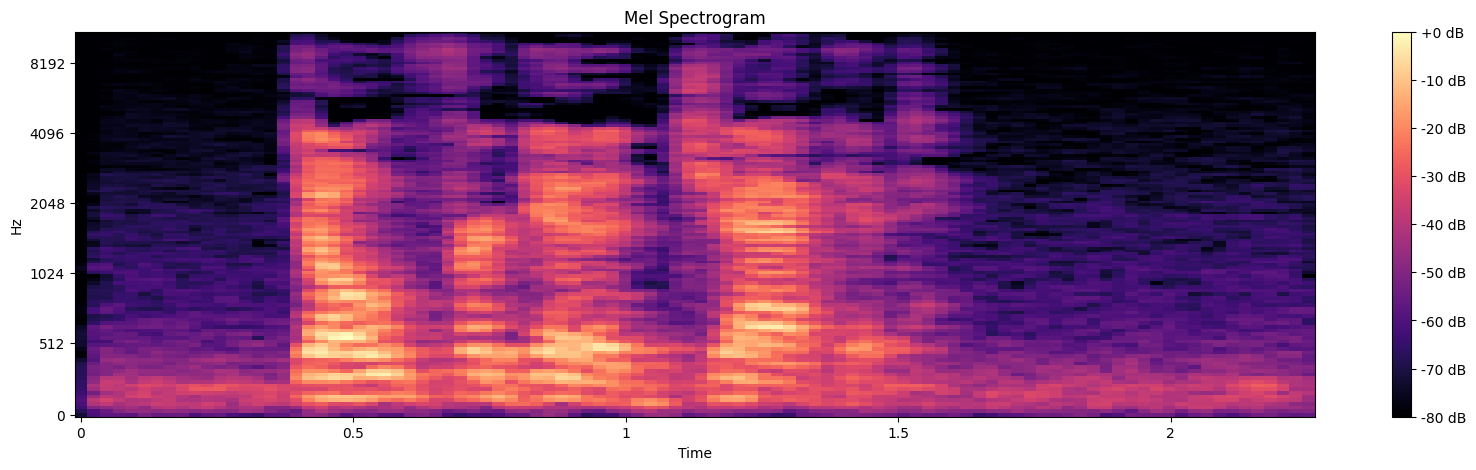

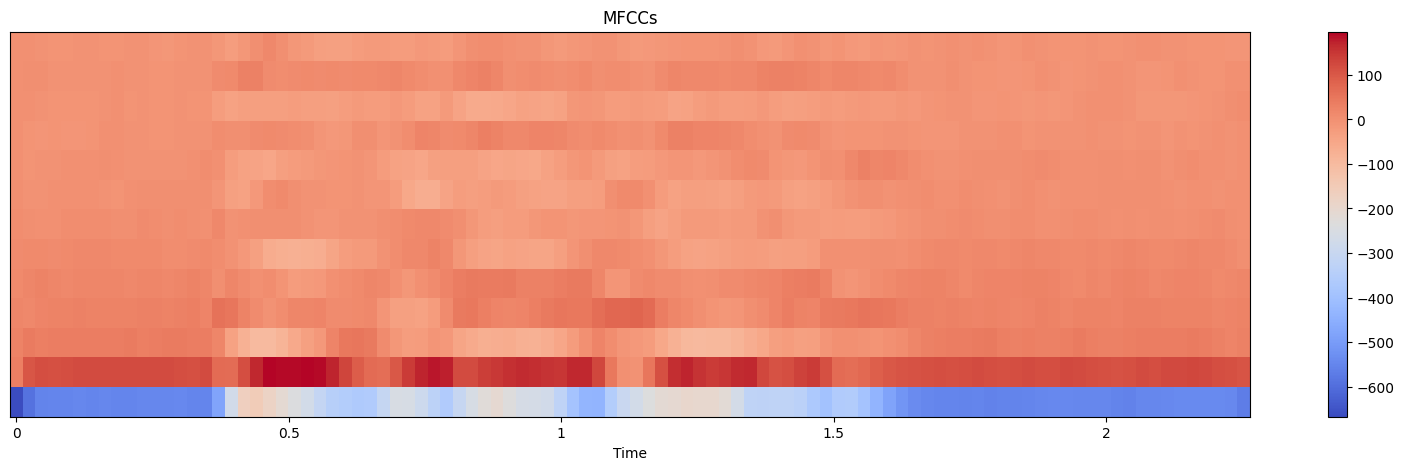

In [19]:
mel_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr)

log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

# Plot the Mel Spectrogram
plt.figure(figsize=(20, 5))
librosa.display.specshow(log_mel_spectrogram, x_axis='time', y_axis='mel', sr=sr, cmap='magma')
plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.show()

mfccs = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=13)

# Plot the MFCCs
plt.figure(figsize=(20, 5))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='coolwarm')
plt.title('MFCCs')
plt.colorbar()
plt.show()

In [20]:
# for each mfcc, compute the mean, std, min, max
mfcc_mean = np.mean(mfccs, axis=1)
mfcc_std = np.std(mfccs, axis=1)
mfcc_min = np.min(mfccs, axis=1)
mfcc_max = np.max(mfccs, axis=1)

mfcc_mean.shape

(13,)

## Create Feature Dataframe for Sample File

In [22]:
features = {}

for i in range(len(zcrs)):
    features[f'zcrs_{i}'] = zcrs[i][0]

for i in range(len(rmss)):
    features[f'rmss_{i}'] = rmss[i][0]

features["centroid_mean"] = centroid_mean
features["centroid_std"] = centroid_std
features["centroid_min"] = centroid_min
features["centroid_max"] = centroid_max
features["centroid_skew"] = centroid_skew
features["centroid_kurt"] = centroid_kurt

features["bandwidth_mean"] = bandwidth_mean
features["bandwidth_std"] = bandwidth_std
features["bandwidth_min"] = bandwidth_min
features["bandwidth_max"] = bandwidth_max
features["bandwidth_skew"] = bandwidth_skew
features["bandwidth_kurt"] = bandwidth_kurt

features["spectral_rolloff_mean"] = spectral_rolloff_mean
features["spectral_rolloff_std"] = spectral_rolloff_std

features["spectral_flatness_mean"] = spectral_flatness_mean
features["spectral_flatness_std"] = spectral_flatness_std

for i in range(len(mfcc_mean)):
    features[f'mfcc_mean_{i}'] = mfcc_mean[i]
    features[f'mfcc_std_{i}'] = mfcc_std[i]
    features[f'mfcc_min_{i}'] = mfcc_min[i]
    features[f'mfcc_max_{i}'] = mfcc_max[i]

df = pd.DataFrame(features, index=[0])
df.head()

,zcrs_0,zcrs_1,zcrs_2,zcrs_3,zcrs_4,zcrs_5,zcrs_6,zcrs_7,zcrs_8,zcrs_9,...,mfcc_min_10,mfcc_max_10,mfcc_mean_11,mfcc_std_11,mfcc_min_11,mfcc_max_11,mfcc_mean_12,mfcc_std_12,mfcc_min_12,mfcc_max_12
0,0.078652,0.059189,0.084872,0.10012,0.114567,0.138242,0.136035,0.045144,0.044944,0.045144,...,-57.694565,4.85682,5.409771,11.133465,-11.580406,30.02224,-9.586636,8.768171,-36.075127,14.819113
